In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

import csv

%cd ..
from scripts import *

/Users/sergejpelko/Desktop/Rudolfovo/coloring_max_stable_set


In [58]:
INSTANCES = {
    # "hamming6_2": "instances/stable_set/hamming6_2_stable_set_edge_list.txt",
    # "hamming6_4": "instances/stable_set/hamming6_4_stable_set_edge_list.txt",
    # "paley61":    "instances/stable_set/paley61_stable_set_edge_list.txt",
    # "dsjc125.9":  "instances/stable_set/dsjc125.9_stable_set_edge_list.txt",
    # "keller4":    "instances/stable_set/keller4_stable_set_edge_list.txt",
    # "MANN_9":     "instances/stable_set/MANN_a9_stable_set_edge_list.txt",
    # "C125.9":     "instances/stable_set/C125.9_stable_set_edge_list.txt",
    # "evil_myc5x24": "instances/stable_set/evil-N120-p98-myc5x24_stable_set_edge_list.txt",
    "brock800_4": "instances/stable_set/brock800_4_stable_set_edge_list.txt",
    "p_hat1500_3": "instances/stable_set/p_hat1500_3_stable_set_edge_list.txt",
    "sanr200-0-7": "instances/stable_set/sanr200-0-7_stable_set_edge_list.txt",
    "c-fat500-5": "instances/stable_set/c-fat500-5_stable_set_edge_list.txt",
}

TRUE_VALUES = {
    "hamming6_2": 32,
    "hamming6_4": 4,
    # "paley61": 5,
    "dsjc125.9": 34,
    # "keller4": 11,
    # "MANN_9": 16,
    "C125.9": 34,
    "evil_myc5x24": 48,
    "brock800_4": 26,
    "p_hat1500_3": 94,
    "sanr200-0-7": 30,
    "c-fat500-5": 64,
}
A = 1.0
B_RATIOS = [1.5, 2, 3, 5, 7, 10, 15, 20]
BASES = [3, 4, 5, 6, 7, 8, 10, 12, 15, 18, 20]
NUM_ATTEMPTS = 100
MAX_ITERS = 100000
SEED = 0

In [59]:
param_sweep_path = "./results/param_sweep_results.csv"

with open(param_sweep_path, 'r') as f:
    reader = csv.DictReader(f)
    data = list(reader)
data[0]

{'instance': 'brock800_4',
 'n': '800',
 'm': '111957',
 'A': '1.0',
 'B': '1.5',
 'ratio': '1.5',
 'base': '3',
 'best': '15',
 'mean': '5.22',
 'std': '4.455513438426598',
 'sizes': '[12, 12, 3, 4, 1, 13, 1, 3, 3, 3, 3, 6, 3, 5, 2, 2, 2, 2, 12, 3, 12, 2, 1, 3, 1, 1, 3, 2, 5, 2, 15, 2, 5, 15, 3, 7, 3, 3, 1, 3, 11, 13, 4, 12, 1, 3, 12, 3, 3, 3, 11, 5, 9, 11, 3, 2, 3, 12, 2, 4, 1, 1, 13, 1, 13, 3, 2, 13, 2, 2, 14, 13, 12, 2, 12, 12, 1, 2, 2, 13, 1, 4, 1, 1, 13, 4, 2, 3, 4, 3, 1, 12, 2, 6, 4, 1, 4, 6, 3, 2]'}

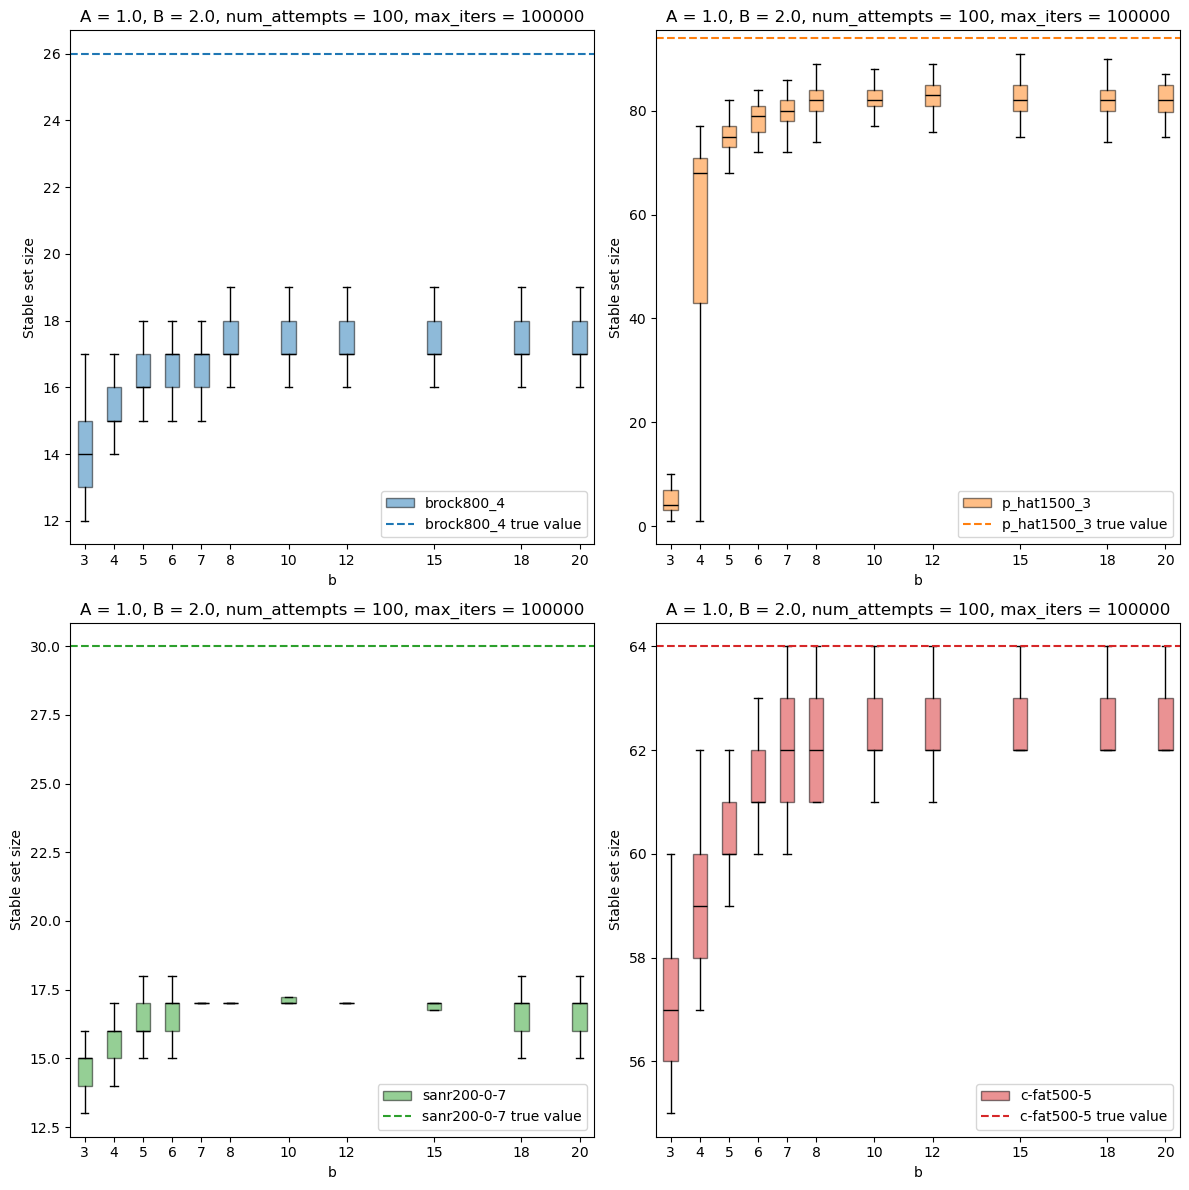

In [60]:

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

ratio = "2"
fig, ax = plt.subplots(2, 2, figsize=(12, 12))
for i, (instance, size) in enumerate(INSTANCES.items()):
    data_per_instance = [e for e in data if e["instance"] == instance]
    data_per_base = [e for e in data_per_instance if e["ratio"] == ratio]
    bases = np.array([int(e["base"]) for e in data_per_base])
    sizes = np.array([e["sizes"] for e in data_per_base])
    sizes = [list(map(int, s.strip("[]").split(","))) for s in sizes]
    # plt.boxplot(sizes, positions=bases, widths=0.5, patch_artist=True, boxprops=dict(facecolor=colors[i], alpha=0.5), medianprops=dict(color="black"), showfliers=False, label=f"{instance}")
    # plt.axhline(y=TRUE_VALUES[instance], color=colors[i], linestyle="--", label=f"{instance} true value")
    ax[i//2, i%2].boxplot(sizes, positions=bases, widths=0.5, patch_artist=True, boxprops=dict(facecolor=colors[i], alpha=0.5), medianprops=dict(color="black"), showfliers=False, label=f"{instance}")
    ax[i//2, i%2].axhline(y=TRUE_VALUES[instance], color=colors[i], linestyle="--", label=f"{instance} true value")

    # ax[i//2, i%2].set_ylim(0, TRUE_VALUES[instance] + 1)
    ax[i//2, i%2].legend()
    ax[i//2, i%2].set_xlabel("b")
    ax[i//2, i%2].set_ylabel("Stable set size")
    ax[i//2, i%2].set_title(f"A = {A}, B = {float(ratio) * A}, num_attempts = {NUM_ATTEMPTS}, max_iters = {MAX_ITERS}")

plt.tight_layout()
plt.savefig(f"./results/param_sweep_results_A{A}_B{float(ratio) * A}_num_attempts{NUM_ATTEMPTS}_max_iters{MAX_ITERS}.png")
plt.show()

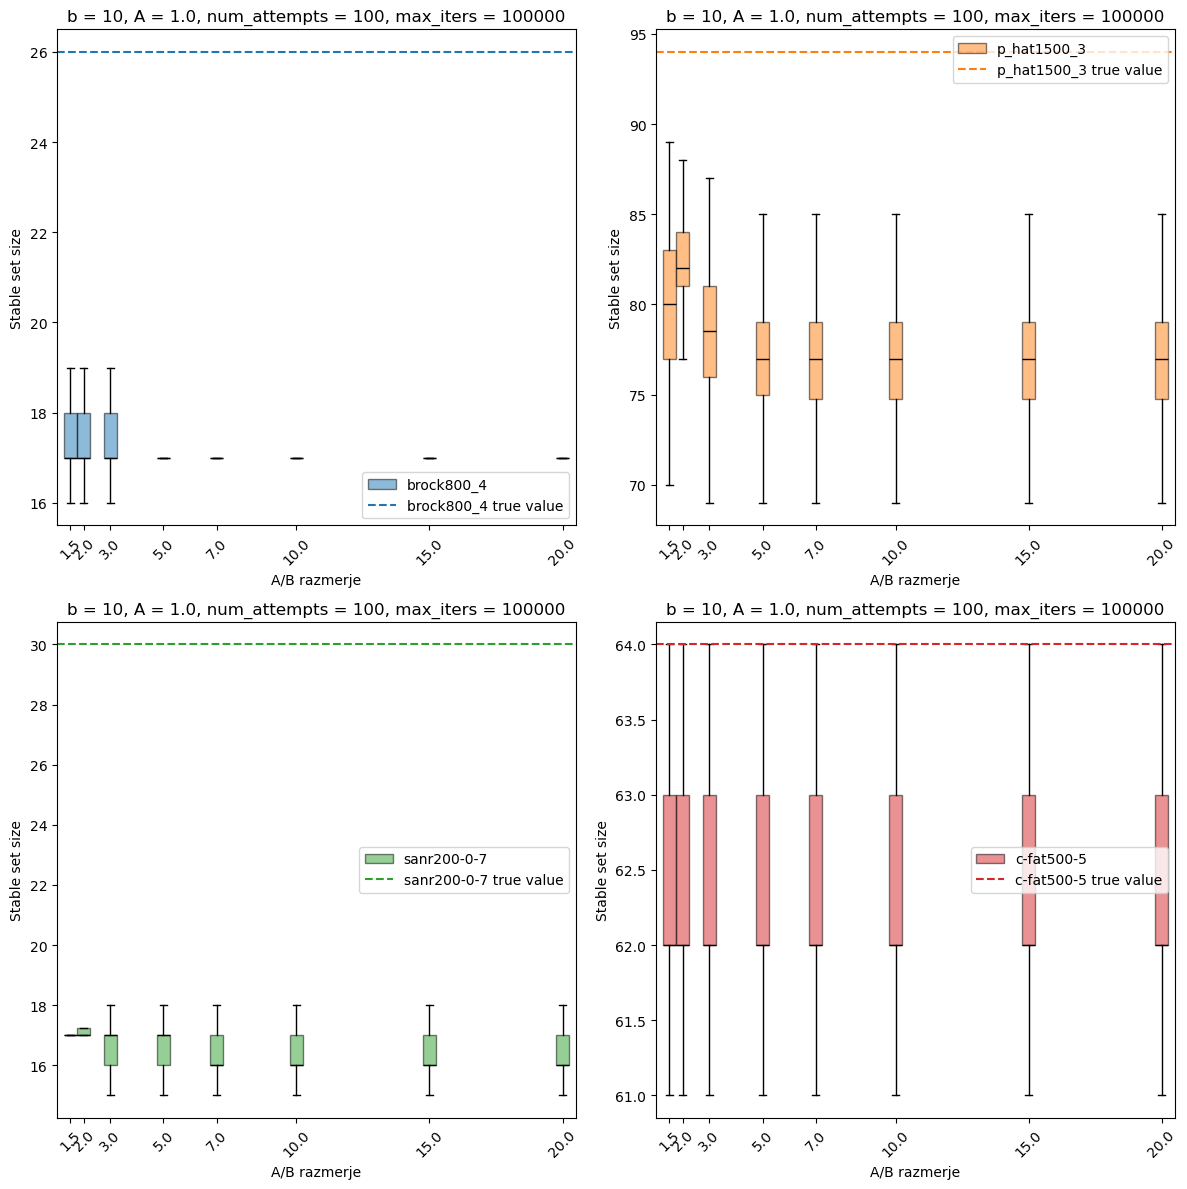

In [61]:

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

base = "10"
fig, ax = plt.subplots(2,2, figsize=(12,12))

for i, (instance, size) in enumerate(INSTANCES.items()):
    data_per_instance = [e for e in data if e["instance"] == instance]
    data_per_base = [e for e in data_per_instance if e["base"] == base]
    ratios = np.array([float(e["ratio"]) for e in data_per_base])
    sizes = np.array([e["sizes"] for e in data_per_base])
    sizes = [list(map(int, s.strip("[]").split(","))) for s in sizes]
    ax[i//2, i%2].boxplot(sizes, positions=ratios, widths=0.5, patch_artist=True, boxprops=dict(facecolor=colors[i], alpha=0.5), medianprops=dict(color="black"), showfliers=False, label=f"{instance}")
    ax[i//2, i%2].axhline(y=TRUE_VALUES[instance], color=colors[i], linestyle="--", label=f"{instance} true value")
    ax[i//2, i%2].set_xlabel("A/B ratio")
    ax[i//2, i%2].set_ylabel("Stable set size")
    ax[i//2, i%2].set_title(f"{instance}")
    # ax[i//2, i%2].set_ylim(0, TRUE_VALUES[instance] + 1)
    ax[i//2, i%2].legend()
    ax[i//2, i%2].set_xlabel("A/B razmerje")
    ax[i//2, i%2].set_ylabel("Stable set size")
    ax[i//2, i%2].tick_params(axis='x', labelrotation=45)
    ax[i//2, i%2].set_title(f"b = {base}, A = {A}, num_attempts = {NUM_ATTEMPTS}, max_iters = {MAX_ITERS}")


plt.tight_layout()
# plt.savefig(f"./results/param_sweep_results_base{base}_A{A}_num_attempts{NUM_ATTEMPTS}_max_iters{MAX_ITERS}.png")
plt.show()


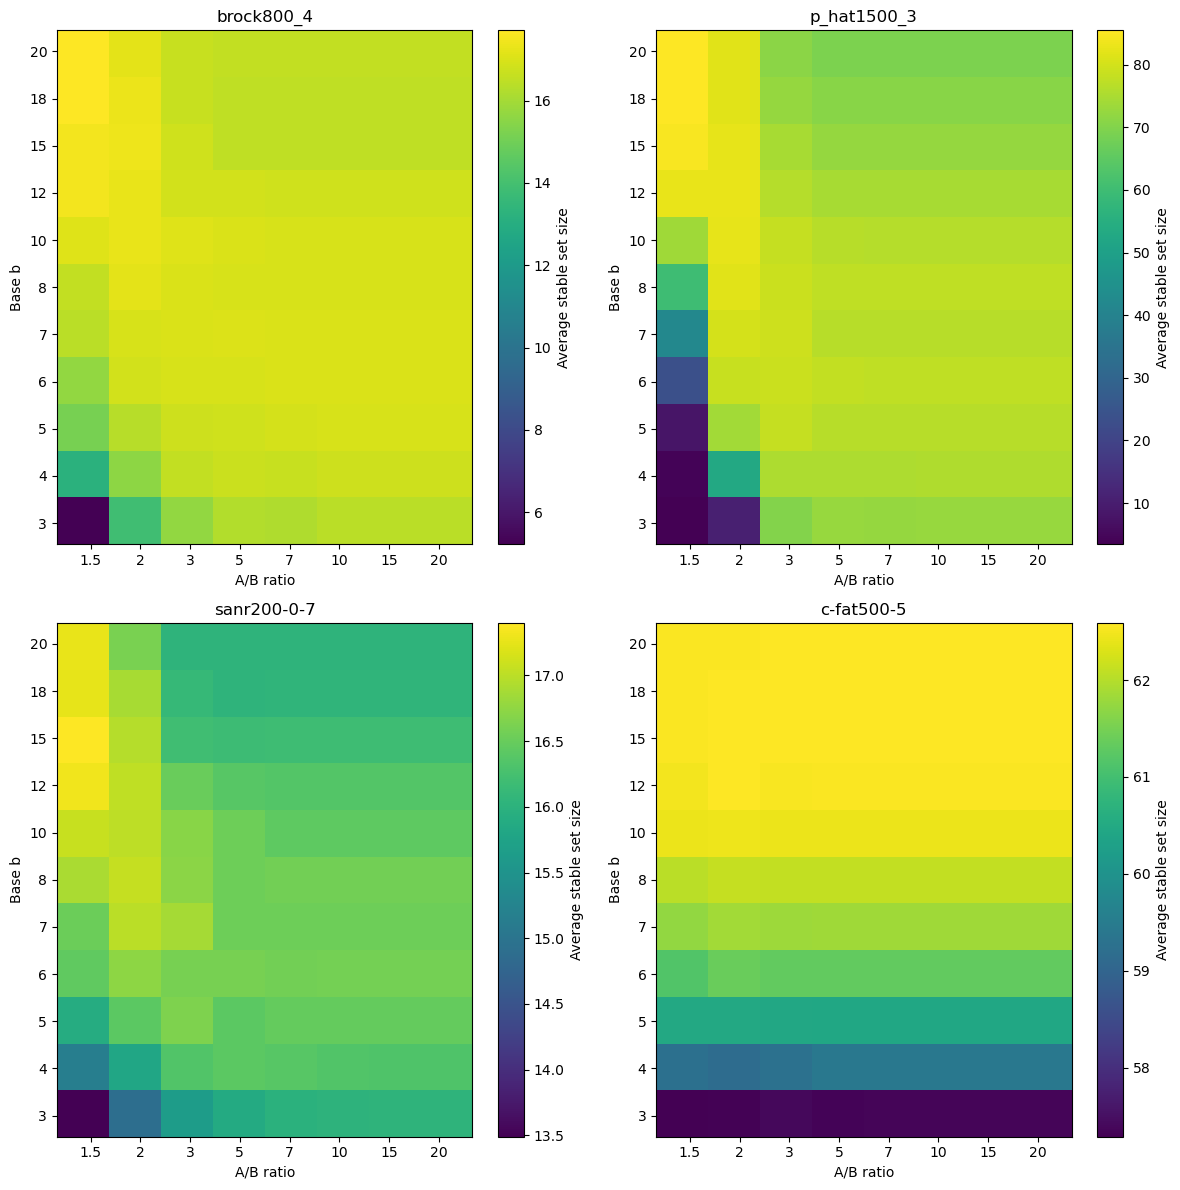

In [63]:
fig, ax = plt.subplots(2,2, figsize=(12,12))


for i, (instance, size) in enumerate(INSTANCES.items()):
    data_per_instance = [e for e in data if e["instance"] == instance]
    bases = np.array([int(e["base"]) for e in data_per_instance])
    ratios = np.array([float(e["ratio"]) for e in data_per_instance])
    sizes = np.array([e["sizes"] for e in data_per_instance])
    sizes = [list(map(int, s.strip("[]").split(","))) for s in sizes]
    sizes_mean = [np.mean(s) for s in sizes]
    sizes_mean_matrix = np.zeros((len(BASES), len(B_RATIOS)))
    for j, b in enumerate(BASES):
        for k, r in enumerate(B_RATIOS):
            idx = np.where((bases == b) & (ratios == r))[0]
            if len(idx) > 0:
                sizes_mean_matrix[j, k] = sizes_mean[idx[0]]
            else:
                sizes_mean_matrix[j, k] = np.nan
    im = ax[i//2, i%2].imshow(sizes_mean_matrix, cmap='viridis', aspect='auto', origin='lower', extent=[min(B_RATIOS), max(B_RATIOS), min(BASES), max(BASES)])
    ax[i//2, i%2].set_xticks(np.linspace(min(B_RATIOS)+1.5, max(B_RATIOS)-1.5, len(B_RATIOS)))
    ax[i//2, i%2].set_xticklabels(B_RATIOS)
    ax[i//2, i%2].set_yticks(np.linspace(min(BASES)+0.7, max(BASES)-0.7, len(BASES)))
    ax[i//2, i%2].set_yticklabels(BASES)
    ax[i//2, i%2].set_xlabel("A/B ratio")
    ax[i//2, i%2].set_ylabel("Base b")
    ax[i//2, i%2].set_title(f"{instance}")
    cbar = plt.colorbar(im, ax=ax[i//2, i%2])
    cbar.set_label('Average stable set size')

plt.tight_layout()
plt.savefig(f"./results/param_sweep_results_heatmap_A{A}_num_attempts{NUM_ATTEMPTS}_max_iters{MAX_ITERS}.png")
plt.show()

In [64]:
# benchmark_stable_set_path_old = "results/benchmark_stable_set_results_old.csv"
# benchmark_results_old = pd.read_csv(benchmark_stable_set_path_old)

# benchmark_results_old = benchmark_results_old.drop(columns=["A", "B", "base", "std"])
# benchmark_results_old["error"] = benchmark_results_old["gap"] / benchmark_results_old["known_best"]
# with open("report/table_old.tex", "w") as f:
#     f.write(benchmark_results_old.to_latex(index=False, float_format="%.2f", escape=True))

benchmark_stable_set_path = "results/benchmark_stable_set_results.csv"
benchmark_results = pd.read_csv(benchmark_stable_set_path)

benchmark_results = benchmark_results.drop(columns=["A", "B", "b", "std"])
with open("report/table.tex", "w") as f:
    f.write(benchmark_results.to_latex(index=False, float_format="%.2f", escape=True))

In [10]:
benchmark_stable_set_path = "results/benchmark_stable_set_results.csv"
benchmark_stable_set_old_algo_path = "results/benchmark_stable_set_results_old_algo.csv"
benchmark_results = pd.read_csv(benchmark_stable_set_path)
benchmark_results_old_algo = pd.read_csv(benchmark_stable_set_old_algo_path)
benchmark_results = benchmark_results.drop(columns=["A", "B", "b", "std", "mean"])
benchmark_results_old_algo = benchmark_results_old_algo.drop(columns=["A", "B", "base", "std", "n", "m", "num_attempts", "max_iters", "known_best", "mean"])
benchmark_results_old_algo = benchmark_results_old_algo.rename(columns={"best": "best_old_algo", "time_sec": "time_sec_old_algo", "gap": "gap_old_algo"})
benchmark_results_combined = pd.merge(benchmark_results, benchmark_results_old_algo, on="instance", how="inner")
benchmark_results_combined = benchmark_results_combined[[
    "instance", "n", "m", "max_iters", "num_attempts", "best", "time_sec", "gap", "best_old_algo", "time_sec_old_algo", "gap_old_algo", "sa_best", "sa_total_time_sec", "sa_gap"
]]
with open("report/table_combined.tex", "w") as f:
    f.write(benchmark_results_combined.to_latex(index=False, float_format="%.2f", escape=True))

Target value 4 reached at iteration 93, terminating early.
Target value 4 reached at iteration 250, terminating early.
Target value 4 reached at iteration 33, terminating early.
Target value 4 reached at iteration 277, terminating early.
Target value 4 reached at iteration 100, terminating early.
Target value 4 reached at iteration 38, terminating early.
Target value 4 reached at iteration 279, terminating early.
Target value 4 reached at iteration 174, terminating early.
Target value 4 reached at iteration 204, terminating early.
Target value 4 reached at iteration 289, terminating early.
Target value 5 reached at iteration 197, terminating early.
Target value 5 reached at iteration 152, terminating early.
Target value 5 reached at iteration 234, terminating early.
Target value 5 reached at iteration 144, terminating early.
Target value 5 reached at iteration 15, terminating early.
Target value 5 reached at iteration 43, terminating early.
Target value 5 reached at iteration 61, termi

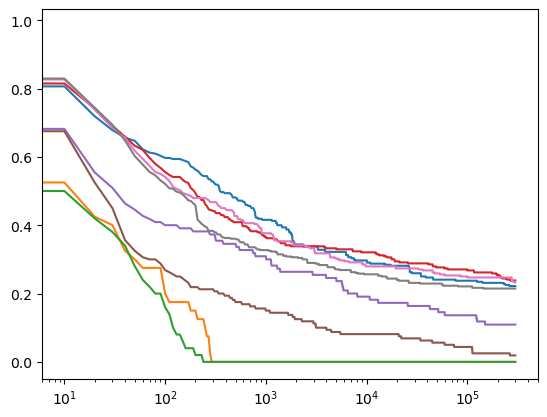

In [55]:
n_repeats = 10
max_iters = 300000
record_every = 10

for name, instance in INSTANCES.items():
    graph = CSRGraph.from_edge_list_file(INSTANCES[name])
    histories = np.ones((n_repeats, max_iters // record_every)) * TRUE_VALUES[name]
    for n in range(n_repeats):
        problem = MaxStableSetProblem(graph, A=1.0, B=2.0)

        state, history = petford_welsh(
            problem,
            b=4,
            max_iters=max_iters,
            rng=np.random.default_rng(),
            record_every=record_every,
            target=TRUE_VALUES[name]
        )
        histories[n, :len(history)] = np.sum(history, axis=1)

    best_values = np.mean(histories, axis=0)
    gap = (TRUE_VALUES[name] - best_values) / TRUE_VALUES[name]
    t = np.arange(0, max_iters, record_every)

    plt.semilogx(t[:len(gap)], gap)

plt.show()